## 1. 导入和配置

In [2]:
import sys
from pathlib import Path

# 确保 stats_utils 可导入
sys.path.insert(0, str(Path('.').resolve()))
from stats_utils import *

setup_plotting()

# 输出路径
OUTPUT_PATH = BASE_PATH / 'reports' / 'comparison' / 'frequency'
OUTPUT_PATH, FIGURES_PATH = ensure_output_dirs(OUTPUT_PATH)

print(f'输出目录: {OUTPUT_PATH}')
print(f'图片目录: {FIGURES_PATH}')

输出目录: d:\LYW\REST_COM\reports\comparison\frequency
图片目录: d:\LYW\REST_COM\reports\comparison\frequency\figures


## 2. 数据加载

In [3]:
import pandas as pd

def load_frequency_data() -> pd.DataFrame:
    """加载三组频域数据 (subject_band_powers.csv)"""
    dfs = []
    for g in GROUPS:
        csv_path = FREQ_PATHS[g] / 'subject_band_powers.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df['group'] = g
            dfs.append(df)
            print(f'  {GROUP_LABELS[g]}: {len(df)} 被试')
        else:
            print(f'  ⚠ 未找到: {csv_path}')
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


print('--- 加载频域数据 ---')
freq_df = load_frequency_data()
print(f'\n频域数据: {freq_df.shape}')
freq_df.head()

--- 加载频域数据 ---
  ADHD单纯组: 12 被试
  ADHD共患阅读困难组: 14 被试
  正常发展组: 8 被试

频域数据: (34, 7)


,subject_id,group,Delta,Theta,Alpha,Beta,Gamma
0,18,adhd,2.813040e-11,3.262314e-12,1.681465e-12,2.464228e-13,6.749327e-14
1,29,adhd,1.199479e-11,5.302395e-12,1.799600e-12,3.183868e-13,8.900980e-14
2,31,adhd,1.109306e-11,1.293141e-12,4.601824e-13,1.975893e-13,1.647121e-13
3,37,adhd,2.466549e-11,1.037310e-11,4.341498e-12,1.448976e-12,8.100163e-13
4,38,adhd,9.824419e-12,3.154986e-12,2.931533e-12,4.089642e-13,2.397410e-13


## 3. Omnibus 检验

In [4]:
print('=' * 60)
print('频域指标 Omnibus 检验')
print('=' * 60)

freq_results = []
if not freq_df.empty:
    for band in FREQ_BANDS:
        if band not in freq_df.columns:
            continue
        res = run_analysis_for_metric(freq_df, band, 'band_power', freq_band=band)
        if res:
            freq_results.append(res)
            sig_mark = '***' if res['p'] < 0.001 else '**' if res['p'] < 0.01 else '*' if res['p'] < 0.05 else ''
            print(f"  {band:<8s} | {res['test']:<16s} | "
                  f"p={res['p']:.4f} {sig_mark:>3s} | {res['es_name']}={res['effect_size']:.3f}")

print(f'\n频域检验总数: {len(freq_results)}')

频域指标 Omnibus 检验
  Delta    | Kruskal-Wallis   | p=0.5463     | ε²=-0.026
  Theta    | Kruskal-Wallis   | p=0.5517     | ε²=-0.026
  Alpha    | Kruskal-Wallis   | p=0.8592     | ε²=-0.055
  Beta     | Kruskal-Wallis   | p=0.8739     | ε²=-0.056
  Gamma    | Kruskal-Wallis   | p=0.5812     | ε²=-0.030

频域检验总数: 5


## 4. FDR 校正

In [5]:
freq_omnibus_df = apply_fdr(freq_results)

if not freq_omnibus_df.empty:
    print('频域 Omnibus 结果 (FDR 校正后):')
    print(freq_omnibus_df[['metric', 'freq_band', 'test', 'p', 'p_fdr', 'significant', 'effect_size']].to_string(index=False))

# 汇总事后检验
posthoc_df = collect_posthoc(freq_results)

if not posthoc_df.empty:
    print('\n事后检验结果 (仅 omnibus 显著指标):')
    print(posthoc_df[['metric', 'freq_band', 'pair', 'test', 'p', 'cohens_d', 'significant']].to_string(index=False))

# 保存 CSV
freq_omnibus_df.to_csv(OUTPUT_PATH / 'frequency_omnibus_stats.csv', index=False, encoding='utf-8-sig')
if not posthoc_df.empty:
    posthoc_df.to_csv(OUTPUT_PATH / 'posthoc_stats.csv', index=False, encoding='utf-8-sig')
print('\n✓ 统计结果已保存')

频域 Omnibus 结果 (FDR 校正后):
    metric freq_band           test        p    p_fdr  significant  effect_size
band_power     Delta Kruskal-Wallis 0.546314 0.873931        False    -0.025512
band_power     Theta Kruskal-Wallis 0.551652 0.873931        False    -0.026139
band_power     Alpha Kruskal-Wallis 0.859185 0.873931        False    -0.054724
band_power      Beta Kruskal-Wallis 0.873931 0.873931        False    -0.055822
band_power     Gamma Kruskal-Wallis 0.581225 0.873931        False    -0.029509

✓ 统计结果已保存


## 5. 可视化

In [6]:
# 频域箱线图
if not freq_df.empty:
    for band in FREQ_BANDS:
        if band in freq_df.columns:
            plot_boxplots(freq_df, band,
                          f'{band} 频段功率', f'{band} Power (μV²/Hz)',
                          FIGURES_PATH / f'boxplot_freq_{band}.png')
    print('✓ 频域箱线图已保存')

✓ 频域箱线图已保存


In [7]:
# 效应量森林图
plot_effect_sizes(posthoc_df, FIGURES_PATH / 'effect_sizes_forest.png')

# 显著性热图
plot_significance_heatmap(freq_omnibus_df, '频域指标 Omnibus p 值 (FDR)',
                          FIGURES_PATH / 'heatmap_freq_significance.png')
print('✓ 可视化完成')

  无显著事后检验结果, 跳过森林图
✓ 可视化完成


## 6. 生成报告

In [8]:
# 描述性统计
desc_sections = ['### 频域指标\n']
if not freq_df.empty:
    for band in FREQ_BANDS:
        if band in freq_df.columns:
            desc_sections.append(f'**{band}:**\n')
            desc_sections.append(format_desc_table(freq_df, band))
desc_text = '\n'.join(desc_sections)

# Omnibus 表格
omnibus_text = format_omnibus_table(freq_omnibus_df, '频域指标')

# 事后检验表格
posthoc_text = format_posthoc_table(posthoc_df)

# 样本量
sample_sizes = {g: len(freq_df[freq_df['group'] == g]) for g in GROUPS}

report = generate_report(
    title='频域功率组间统计比较报告',
    analysis_desc='频域功率: Delta, Theta, Alpha, Beta, Gamma (5 检验)',
    sample_sizes=sample_sizes,
    desc_text=desc_text,
    omnibus_text=omnibus_text,
    posthoc_text=posthoc_text,
)

report_file = OUTPUT_PATH / 'frequency_comparison_report.md'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'✓ 报告已保存: {report_file}')

✓ 报告已保存: d:\LYW\REST_COM\reports\comparison\frequency\frequency_comparison_report.md


## 7. 分析完成

In [9]:
print('=' * 60)
print('频域功率统计分析完成!')
print('=' * 60)

print(f'\n输出文件:')
for f in sorted(OUTPUT_PATH.glob('*')):
    if f.is_file():
        print(f'  - {f.name}')

print(f'\n可视化文件:')
for f in sorted(FIGURES_PATH.glob('*.png')):
    print(f'  - {f.name}')

# 显著结果摘要
print('\n' + '=' * 60)
print('显著结果摘要 (FDR < 0.05)')
print('=' * 60)

if not freq_omnibus_df.empty:
    sig = freq_omnibus_df[freq_omnibus_df['significant']]
    print(f'\n频域功率: {len(sig)}/{len(freq_omnibus_df)} 项显著')
    if len(sig) > 0:
        print(sig[['metric', 'freq_band', 'p_fdr', 'effect_size']].to_string(index=False))
    else:
        print('  无显著结果')

频域功率统计分析完成!

输出文件:
  - frequency_comparison_report.md
  - frequency_omnibus_stats.csv

可视化文件:
  - boxplot_freq_Alpha.png
  - boxplot_freq_Beta.png
  - boxplot_freq_Delta.png
  - boxplot_freq_Gamma.png
  - boxplot_freq_Theta.png
  - heatmap_freq_significance.png

显著结果摘要 (FDR < 0.05)

频域功率: 0/5 项显著
  无显著结果


## 8. Trial-level 数据加载

**目标:** 加载每个被试的每个trial的频段功率，构建长格式DataFrame

**数据结构:** `[subject_id, group, trial_idx, band, power, log_power]`

In [14]:
# 定义变量
BANDS = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30), 'Gamma': (30, 45)}
EPOCH_DATA_PATH = BASE_PATH / 'preprocessing' / 'data' / '6epoch_clean'

SUBJECT_GROUPS = {}
for group in GROUPS:
    group_path = EPOCH_DATA_PATH / group
    if group_path.exists():
        SUBJECT_GROUPS[group] = [f.stem.replace('-epo', '') for f in group_path.glob('*-epo.fif')]

print('被试分组:')
for g in GROUPS:
    print(f'  {GROUP_LABELS[g]}: {len(SUBJECT_GROUPS[g])} 被试')

# 加载trial-level数据
import mne
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def load_trial_level_frequency_data():
    all_trials = []
    for group in GROUPS:
        print(f'加载 {GROUP_LABELS[group]}...')
        for subject_id in SUBJECT_GROUPS[group]:
            epoch_file = EPOCH_DATA_PATH / group / f'{subject_id}-epo.fif'
            if not epoch_file.exists():
                continue
            epochs = mne.read_epochs(epoch_file, preload=True, verbose=False)
            psd = epochs.compute_psd(method='welch', fmin=0.5, fmax=45, verbose=False)
            psds, freqs = psd.get_data(return_freqs=True)  # shape: (n_epochs, n_channels, n_freqs)
            for trial_idx in range(len(epochs)):
                for band_name, (fmin, fmax) in BANDS.items():
                    freq_mask = (freqs >= fmin) & (freqs < fmax)
                    power = psds[trial_idx, :, freq_mask].mean()
                    all_trials.append({'subject_id': subject_id, 'group': group, 'trial_idx': trial_idx,
                                     'band': band_name, 'power': power, 'log_power': np.log10(power + 1e-20)})
            print(f'  {subject_id}: {len(epochs)} trials')
    return pd.DataFrame(all_trials)

trial_df = load_trial_level_frequency_data()
print(f'总trials: {len(trial_df)}, 被试数: {trial_df["subject_id"].nunique()}')

被试分组:
  ADHD单纯组: 12 被试
  ADHD共患阅读困难组: 14 被试
  正常发展组: 8 被试
加载 ADHD单纯组...
  018: 19 trials
  029: 22 trials
  031: 19 trials
  037: 25 trials
  038: 30 trials
  045: 19 trials
  075: 26 trials
  091: 23 trials
  094: 30 trials
  117: 28 trials
  132: 17 trials
  134: 19 trials
加载 ADHD共患阅读困难组...
  001: 24 trials
  020: 22 trials
  021: 24 trials
  022: 18 trials
  024: 22 trials
  047: 19 trials
  049: 20 trials
  051: 27 trials
  072: 27 trials
  073: 26 trials
  076: 17 trials
  092: 15 trials
  113: 29 trials
  150: 21 trials
加载 正常发展组...
  006: 23 trials
  068: 23 trials
  079: 28 trials
  093: 26 trials
  108: 23 trials
  109: 19 trials
  127: 17 trials
  133: 24 trials
总trials: 3855, 被试数: 34


## 9. LME 分析 - 组间平均水平差异

**模型:** `log_power ~ C(group, Treatment('td')) + (1|subject_id)`

检验组间在平均功率水平上是否有差异

In [15]:
import statsmodels.formula.api as smf

lme_results = {}
for band in BANDS.keys():
    print('=' * 60)
    print(f'频段: {band}')
    print('=' * 60)
    band_df = trial_df[trial_df['band'] == band].copy()
    model = smf.mixedlm("log_power ~ C(group, Treatment('td'))", data=band_df, groups=band_df['subject_id'], re_formula="~1")
    result = model.fit(method='lbfgs')
    
    var_between = result.cov_re.iloc[0, 0]
    var_within = result.scale
    icc = var_between / (var_between + var_within)
    lme_results[band] = {'result': result, 'icc': icc}
    
    print('固定效应:')
    print(result.summary().tables[1])
    print(f'ICC: {icc:.3f}')
    print('模型对比 (vs TD):')
    for param in result.fe_params.index:
        if 'group' in param and 'Intercept' not in param:
            beta = result.fe_params[param]
            se = result.bse_fe[param]
            p = result.pvalues[param]
            group_name = 'ADHD' if 'adhd' in param.lower() else 'COM'
            print(f'  {group_name}: β={beta:.4f}, 95%CI=[{beta-1.96*se:.4f}, {beta+1.96*se:.4f}], p={p:.4f}')

频段: Delta
固定效应:
                                     Coef. Std.Err.         z  P>|z|   [0.025  \
Intercept                          -10.868    0.092  -117.787  0.000  -11.049   
C(group, Treatment('td'))[T.adhd]    0.086    0.119     0.721  0.471   -0.148   
C(group, Treatment('td'))[T.com]     0.033    0.116     0.283  0.777   -0.194   
Group Var                            0.066    0.091                             

                                    0.975]  
Intercept                          -10.687  
C(group, Treatment('td'))[T.adhd]    0.319  
C(group, Treatment('td'))[T.com]     0.259  
Group Var                                   
ICC: 0.637
模型对比 (vs TD):
  ADHD: β=0.0859, 95%CI=[-0.1476, 0.3193], p=0.4711
  COM: β=0.0327, 95%CI=[-0.1940, 0.2595], p=0.7772
频段: Theta
固定效应:
                                     Coef. Std.Err.         z  P>|z|   [0.025  \
Intercept                          -11.623    0.080  -145.773  0.000  -11.779   
C(group, Treatment('td'))[T.adhd]    0.097    0

## 10. 方差异质性检验

检验组间trial-to-trial波动是否不同

In [16]:
from scipy.stats import levene, kruskal

print('方法1: Levene检验')
for band in BANDS.keys():
    band_df = trial_df[trial_df['band'] == band]
    adhd_data = band_df[band_df['group'] == 'adhd']['log_power']
    com_data = band_df[band_df['group'] == 'com']['log_power']
    td_data = band_df[band_df['group'] == 'td']['log_power']
    stat, p = levene(adhd_data, com_data, td_data)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{band}: Levene={stat:.3f}, p={p:.4f} {sig}')

print('')
print('方法2: 被试内标准差比较')
subject_variability = trial_df.groupby(['subject_id', 'group', 'band'])['log_power'].std().reset_index()
subject_variability.columns = ['subject_id', 'group', 'band', 'within_subject_std']

for band in BANDS.keys():
    band_var = subject_variability[subject_variability['band'] == band]
    adhd_std = band_var[band_var['group'] == 'adhd']['within_subject_std']
    com_std = band_var[band_var['group'] == 'com']['within_subject_std']
    td_std = band_var[band_var['group'] == 'td']['within_subject_std']
    stat, p = kruskal(adhd_std, com_std, td_std)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{band}: ADHD={adhd_std.mean():.4f}, COM={com_std.mean():.4f}, TD={td_std.mean():.4f}, H={stat:.3f}, p={p:.4f} {sig}')

方法1: Levene检验
Delta: Levene=6.325, p=0.0019 **
Theta: Levene=13.794, p=0.0000 ***
Alpha: Levene=1.541, p=0.2147 
Beta: Levene=1.894, p=0.1511 
Gamma: Levene=6.917, p=0.0011 **

方法2: 被试内标准差比较
Delta: ADHD=0.1895, COM=0.1948, TD=0.1697, H=0.537, p=0.7646 
Theta: ADHD=0.1279, COM=0.1180, TD=0.1083, H=2.257, p=0.3236 
Alpha: ADHD=0.1581, COM=0.1796, TD=0.1263, H=2.749, p=0.2530 
Beta: ADHD=0.1042, COM=0.0964, TD=0.0792, H=1.910, p=0.3848 
Gamma: ADHD=0.2002, COM=0.2195, TD=0.1496, H=4.827, p=0.0895 


## 11. 模型诊断

检查ICC、残差正态性、方差齐性

ICC汇总:
Delta: ICC=0.637
Theta: ICC=0.772
Alpha: ICC=0.757
Beta: ICC=0.823
Gamma: ICC=0.556


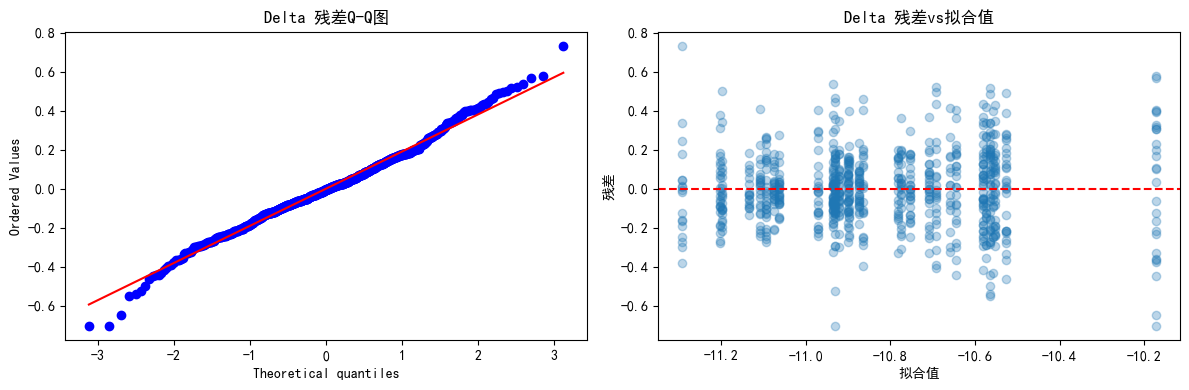

Delta频段诊断图已生成


In [17]:
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

print('ICC汇总:')
for band, res in lme_results.items():
    print(f'{band}: ICC={res["icc"]:.3f}')

# 残差诊断（以Delta为例）
band = 'Delta'
result = lme_results[band]['result']
band_df = trial_df[trial_df['band'] == band].copy()
band_df['fitted'] = result.fittedvalues
band_df['resid'] = result.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sp_stats.probplot(band_df['resid'], dist='norm', plot=axes[0])
axes[0].set_title(f'{band} 残差Q-Q图')
axes[1].scatter(band_df['fitted'], band_df['resid'], alpha=0.3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('拟合值')
axes[1].set_ylabel('残差')
axes[1].set_title(f'{band} 残差vs拟合值')
plt.tight_layout()
plt.show()
print(f'{band}频段诊断图已生成')

## 12. 可视化

固定效应森林图、ICC条形图

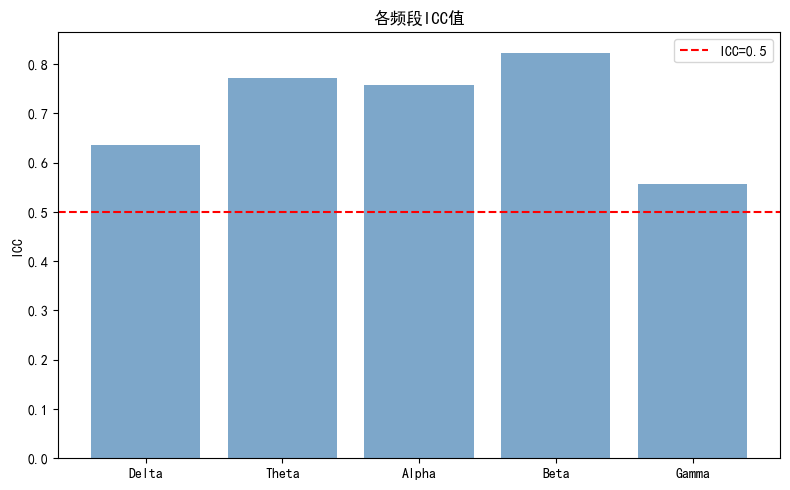

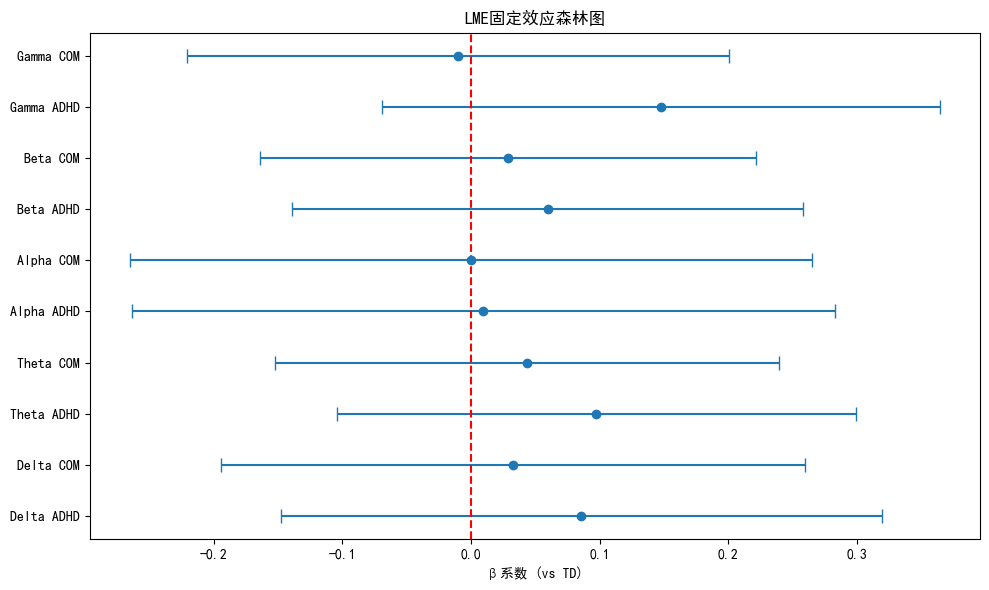

In [18]:
# ICC条形图
fig, ax = plt.subplots(figsize=(8, 5))
bands = list(lme_results.keys())
iccs = [lme_results[b]['icc'] for b in bands]
ax.bar(bands, iccs, color='steelblue', alpha=0.7)
ax.set_ylabel('ICC')
ax.set_title('各频段ICC值')
ax.axhline(0.5, color='red', linestyle='--', label='ICC=0.5')
ax.legend()
plt.tight_layout()
plt.show()

# 固定效应森林图
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = []
y_labels = []
betas = []
cis_lower = []
cis_upper = []

for i, band in enumerate(BANDS.keys()):
    result = lme_results[band]['result']
    for param in result.fe_params.index:
        if 'group' in param and 'Intercept' not in param:
            beta = result.fe_params[param]
            se = result.bse_fe[param]
            group_name = 'ADHD' if 'adhd' in param.lower() else 'COM'
            y_pos.append(len(y_pos))
            y_labels.append(f'{band} {group_name}')
            betas.append(beta)
            cis_lower.append(beta - 1.96*se)
            cis_upper.append(beta + 1.96*se)

ax.errorbar(betas, y_pos, xerr=[[(b-l) for b, l in zip(betas, cis_lower)], [(u-b) for b, u in zip(betas, cis_upper)]], fmt='o', capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('β系数 (vs TD)')
ax.set_title('LME固定效应森林图')
plt.tight_layout()
plt.show()

## 13. 综合报告

LME分析结果总结

In [19]:
print('=' * 70)
print('LME分析结果总结')
print('=' * 70)

print('')
print('1. 组间平均水平差异（固定效应）:')
for band in BANDS.keys():
    result = lme_results[band]['result']
    print(f'{band}:')
    for param in result.fe_params.index:
        if 'group' in param and 'Intercept' not in param:
            p = result.pvalues[param]
            group_name = 'ADHD' if 'adhd' in param.lower() else 'COM'
            sig = '显著' if p < 0.05 else '不显著'
            print(f'  {group_name} vs TD: p={p:.4f} ({sig})')

print('')
print('2. ICC值（被试间相关性）:')
for band, res in lme_results.items():
    icc = res['icc']
    interpretation = 'trial信息有限' if icc > 0.7 else '被试间和被试内都重要' if icc > 0.3 else 'trial变异主导'
    print(f'{band}: ICC={icc:.3f} ({interpretation})')

print('')
print('3. 方法学说明:')
print('- LME固定效应检验组间平均水平差异，与被试水平分析问题相同')
print('- 高ICC表明被试间差异大，trial-level分析的额外信息有限')
print('- 方差异质性检验可发现组间波动差异（即使平均水平相同）')
print('')
print('分析完成！')

LME分析结果总结

1. 组间平均水平差异（固定效应）:
Delta:
  ADHD vs TD: p=0.4711 (不显著)
  COM vs TD: p=0.7772 (不显著)
Theta:
  ADHD vs TD: p=0.3437 (不显著)
  COM vs TD: p=0.6618 (不显著)
Alpha:
  ADHD vs TD: p=0.9452 (不显著)
  COM vs TD: p=0.9985 (不显著)
Beta:
  ADHD vs TD: p=0.5564 (不显著)
  COM vs TD: p=0.7688 (不显著)
Gamma:
  ADHD vs TD: p=0.1823 (不显著)
  COM vs TD: p=0.9258 (不显著)

2. ICC值（被试间相关性）:
Delta: ICC=0.637 (被试间和被试内都重要)
Theta: ICC=0.772 (trial信息有限)
Alpha: ICC=0.757 (trial信息有限)
Beta: ICC=0.823 (trial信息有限)
Gamma: ICC=0.556 (被试间和被试内都重要)

3. 方法学说明:
- LME固定效应检验组间平均水平差异，与被试水平分析问题相同
- 高ICC表明被试间差异大，trial-level分析的额外信息有限
- 方差异质性检验可发现组间波动差异（即使平均水平相同）

分析完成！
